# [A6] Tree-Based Algorithms

In this notebook, a family of supervised learning methods that is especially strong on **tabular data** is introduced: single decision trees and ensemble methods built from many trees.

The aim of this assignment is to train and compare several tree-based classification models on the **Titanic** dataset:
1. `DecisionTreeClassifier` as an interpretable baseline
2. `RandomForestClassifier` as a bagging-based ensemble
3. `XGBClassifier` as a boosting-based ensemble

Tree-based models can capture non-linear relationships and feature interactions without manual feature engineering, and they usually do **not** require feature scaling.

At the same time, they still require careful handling of categorical variables, missing values, and model complexity.

## 1: Foundations

**The complete introduction of the theoretical basics is given in the lecture.**

Tree-based models recursively partition the feature space into smaller regions. Inside each region, the model predicts a single class label or probability. This makes them flexible, easy to visualize, and often surprisingly effective on structured datasets.

* **Decision Trees**: A flowchart-like model. At each node, the algorithm chooses a feature and a threshold that lead to the purest possible split. A deep tree can fit the training data extremely well, but it is also prone to overfitting.
* **Random Forest**: An ensemble learning method based on **bagging** (Bootstrap Aggregating). It trains many different trees on random subsets of the data and combines their predictions by voting. This mainly reduces variance and makes the model more stable.
* **XGBoost (Extreme Gradient Boosting)**: A boosting-based ensemble. Trees are built **sequentially**, and each new tree focuses more strongly on the mistakes of the previous ones. This often leads to excellent predictive performance on tabular data.
* **Feature Importance**: Tree-based models provide a simple notion of interpretability. They keep track of how much each feature reduces impurity across all splits, which allows us to estimate which inputs were most useful for the model.

## 2: About the Dataset and Exploratory Data Analysis (EDA)
The **Titanic** dataset contains passenger-level information such as ticket class, sex, age, fare, and family relations on board. The task is to predict whether a passenger **survived** (`1`) or **died** (`0`).

Before training any model, we should answer four basic questions:
1. How large is the dataset?
2. Is the target distribution balanced or imbalanced?
3. Which features already seem informative for survival?
4. Which columns contain missing values or seem unsuitable for direct modeling?

The following steps help us build this first intuition.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 50

titanic = pd.read_csv('data/original_titanic.csv')
display(titanic.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Home-Dest
0,1,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,"St Louis, MO"
1,2,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
2,3,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
3,4,0,1,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
4,5,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"


## 2.1: ✏️ Explore the dataset

In order to answer the posed questions above, get the following information about the dataset:
- its shape,
- the number of (non)survivors
- the percentage of (non)survivors 
- the number of missing values by column

Additionally, we're plotting the survival by gender and by class to see if there are any correlations.

Also, briefly interpret your observations of these numbers as comments

Shape: (1309, 13)

Survived counts:
Survived
False    1309
Name: count, dtype: int64

Survived relative frequencies:
Survived
0    0.618
1    0.382
Name: proportion, dtype: float64


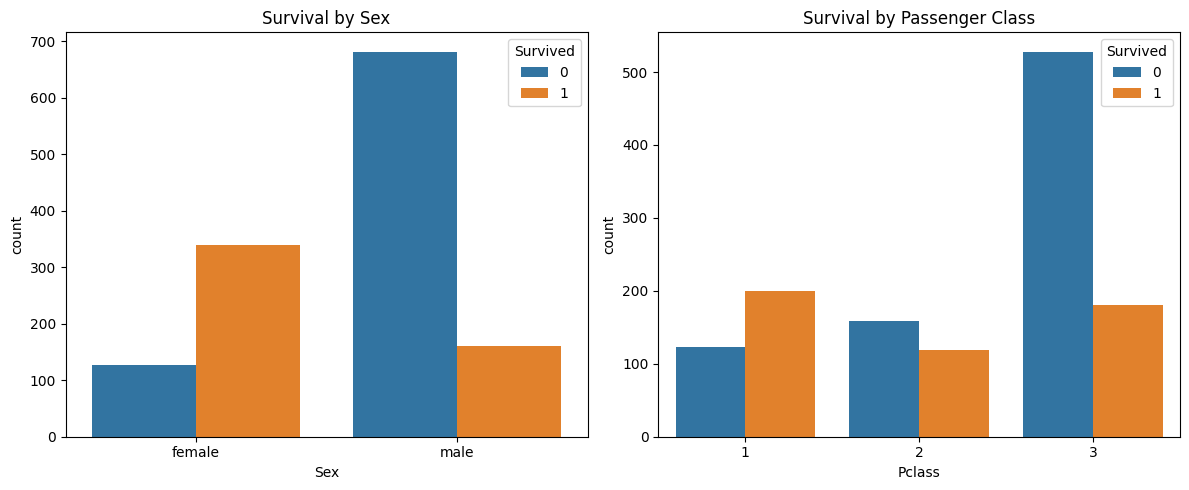


Missing values per column:


Cabin          1014
Home-Dest       564
Age             263
Embarked          2
Fare              1
Sex               0
Name              0
Pclass            0
Survived          0
PassengerId       0
Ticket            0
SibSp             0
Parch             0
dtype: int64

In [88]:
titanic_shape = []
survived_counts = []
survived_frequencies = []
missing_values = []

# TODO: Implement
titanic_shape = titanic.shape
survived_counts = titanic['Survived'].isnull().value_counts()
survived_frequencies = titanic['Survived'].value_counts(normalize=True)
missing_values = titanic.isnull().sum()

print('Shape:', titanic_shape)
print('\nSurvived counts:')
print(survived_counts)
print('\nSurvived relative frequencies:')
print(survived_frequencies.round(3))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=titanic, x='Sex', hue='Survived')
plt.title('Survival by Sex')

plt.subplot(1, 2, 2)
sns.countplot(data=titanic, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')

plt.tight_layout()
plt.show()

print('\nMissing values per column:')
display(missing_values.sort_values(ascending=False))

## 3: ✏️ Preprocessing
Tree-based models do **not** require feature scaling such as normalization or standardization. This is one of their major practical advantages compared to methods such as PCA, K-Means, or gradient-based neural networks.

However, the models still require a **numerical feature matrix** and a clean split into training and test data. In this exercise, we will:
1. **Drop unsuitable columns**: Identifiers and free-text-like columns such as `Name`, `Ticket`, `Cabin`, `PassengerId`, and `Home-Dest` are not used in this introductory example. 

In [89]:
df = titanic.copy()
columns_to_drop = ['Name', 'Cabin', 'Ticket', 'PassengerId', 'Home-Dest']

# TODO: Implement
df2 = df.drop(columns_to_drop, axis=1)

2. **Encode categorical variables**: `Sex` and `Embarked` will be transformed into numeric dummy columns using one-hot encoding. Create a new dataframe `df3` where the result is stored.

In [90]:
# TODO: Implement
df3 = pd.get_dummies(df2, columns=['Sex', 'Embarked'], drop_first=True)

3. **Create a train/test split**: Since `Survived` is not perfectly balanced, it is good practice to use `stratify=y` so that both subsets retain a similar class distribution. For the split, use `test_size=0.2` and `random_state=42` as additional parameters.

In [91]:
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = None, None, None, None
df4_y = df3['Survived']
df4_x = df3.drop('Survived', axis=1)
# TODO: Implement
X_train, X_test, y_train, y_test = train_test_split(
    df4_x, df4_y, test_size=0.2, random_state=42, stratify=df4_y
)

display(X_train.head())

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
999,3,NaN,0,0,7.7500,False,True,False
392,2,24.0,1,0,27.7208,False,False,False
628,3,11.0,4,2,31.2750,False,False,True
1165,3,25.0,0,0,7.2250,True,False,False
604,3,16.0,0,0,7.6500,False,False,True


## 4: ✏️ Dealing with Missing Values
After preprocessing, the largest missing-value problem is still the `Age` column. In addition, depending on the train/test split, there may also be isolated missing values in other numeric columns such as `Fare`.

The basic `DecisionTreeClassifier` and `RandomForestClassifier` implementations from scikit-learn cannot handle `NaN` values directly. Therefore, we need an imputation step before training these models.

To avoid **data leakage**, always fit the imputer only on the training set. Afterwards, apply the learned transformation to the test set.

For this exercise, median imputation is a sensible default because it is simple and fairly robust against outliers.

1. Identify all columns in X_train that still contain missing values

In [92]:
missing_cols = ['Age', 'Fare']
# TODO: Implement

print('Missing columns:', list(missing_cols))

Missing columns: ['Age', 'Fare']


2. Create a SimpleImputer with strategy `median`, fit it on `X_train[missing_cols]` and then transform both splits.

In [93]:
from sklearn.impute import SimpleImputer

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[missing_cols])

X_train_imputed[missing_cols] = imputer.fit_transform(X_train[missing_cols])
X_test_imputed[missing_cols] = imputer.transform(X_test[missing_cols])

3. Verify that the imputed training and test sets no longer contain missing values.

In [94]:
num_missing_vals_train = -1
num_missing_vals_test = -1

# TODO: Implement
num_missing_vals_train = X_train_imputed[missing_cols].isnull().sum().sum()
num_missing_vals_test = X_test_imputed[missing_cols].isnull().sum().sum()

print('Remaining missing values in X_train_imputed:', num_missing_vals_train)
print('Remaining missing values in X_test_imputed:', num_missing_vals_test)


Remaining missing values in X_train_imputed: 0
Remaining missing values in X_test_imputed: 0


## 5: ✏️ Implementing the Decision Tree Baseline
A single `DecisionTreeClassifier` is the simplest model in this family. It is highly interpretable because we can inspect the sequence of split rules directly.

At the same time, a deep tree can easily memorize the training data. To keep the model simple and reduce overfitting, we limit the depth via `max_depth=3`.

When evaluating the model, compare **training accuracy** and **test accuracy**. If the training accuracy is much higher than the test accuracy, this is a warning sign for overfitting.

1. Create and fit a `DecisionTreeClassifier` `dt_clf` with a maximum depth of `3` and initialize it in `random_state=42`.

In [95]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# TODO: Implement 
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train_imputed, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

2. Predict on both X_train_imputed and X_test_imputed. Store the accuracies as `dt_train_acc` and `dt_test_acc`.

In [96]:
dt_train_acc = -1.0
dt_test_acc = -1.0

#TODO: Implement
dt_train_acc = dt_clf.score(X_train_imputed, y_train)
dt_test_acc = dt_clf.score(X_test_imputed, y_test)


print('Decision Tree Train Accuracy:', dt_train_acc)
print('Decision Tree Test Accuracy:', dt_test_acc)

Decision Tree Train Accuracy: 0.8118433619866284
Decision Tree Test Accuracy: 0.8358778625954199


3. Finally, we visualize the trained tree with `plot_tree`. Use the `columns` of our imputed train as `feature_names`.

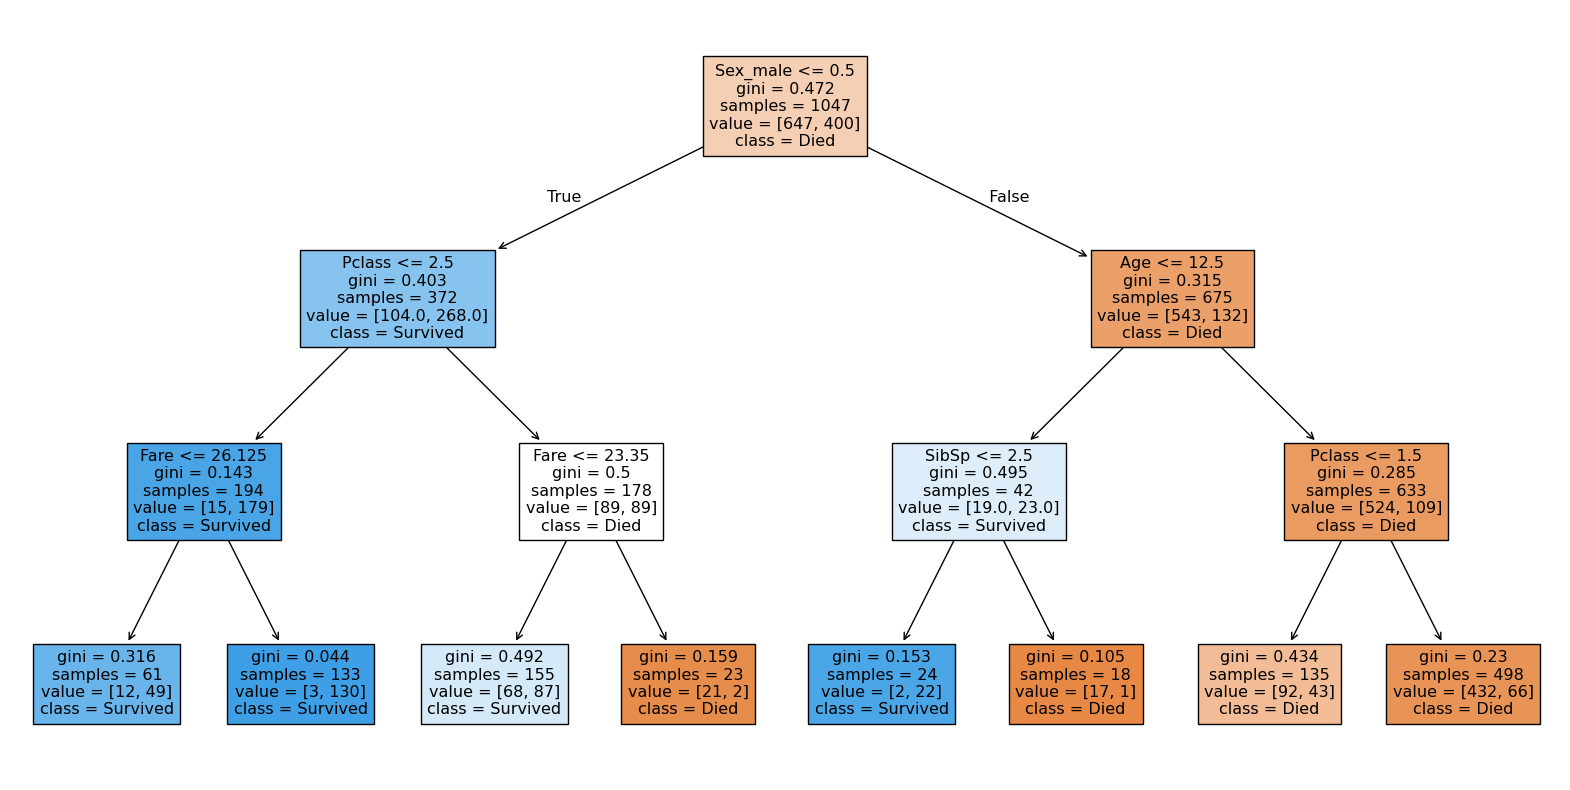

In [97]:
class_names = ['Died', 'Survived']

plt.figure(figsize=(20, 10))

# TODO: Implement
plot_tree(dt_clf, feature_names=X_train_imputed.columns, class_names=class_names, filled=True)

plt.show()

## 6:  Transitioning to Random Forests
A single decision tree is sensitive to noise and to small changes in the training data. A **Random Forest** reduces this instability by combining many trees that each see slightly different views of the data.

Two key ideas are used:
- **Bootstrap sampling**: every tree is trained on a random sample of the training data.
- **Random feature subsets**: at each split, only a subset of features is considered.

The final prediction is obtained by aggregating the predictions of all trees. In practice, this often improves generalization performance compared to a single tree.

However, even a Random Forest can overfit on a relatively small dataset if the individual trees are allowed to grow too deep. We therefore start with a slightly regularized forest and limit `max_depth`.

1. Create and train a `RandomForestClassifier` `rf_clf` with `100 estimators, a maximum depth of `5`and the same `random_state` as above. 

In [98]:
from sklearn.ensemble import RandomForestClassifier

# TODO: Implement
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train_imputed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

2. Predict on both X_train_imputed and X_test_imputed. Store the accuracies as `rf_train_acc` and `rf_test_acc`.

In [99]:
rf_train_acc = -1.0
rf_test_acc = -1.0

# TODO: Implement
rf_train_acc = rf_clf.score(X_train_imputed, y_train)
rf_test_acc = rf_clf.score(X_test_imputed, y_test)

print('Random Forest Train Accuracy:', rf_train_acc)
print('Random Forest Test Accuracy:', rf_test_acc)

Random Forest Train Accuracy: 0.8319006685768864
Random Forest Test Accuracy: 0.8587786259541985


In [100]:
# TODO: Compare the result to the single Decision Tree in a short comment.
# The Reandom Forest is slightly better than the single decision tree.

## 7: ✏️ Pushing Limits with XGBoost
Boosting follows a different idea than bagging: instead of building many independent trees in parallel, the model is improved **sequentially**. Each new tree focuses more strongly on the mistakes that the current ensemble still makes.

`XGBoost` is one of the most successful boosting implementations for structured tabular data.

**Special feature**: XGBoost can handle missing values (`NaN`) internally. It learns a default direction for missing values during training. This means we can train it directly on the original `X_train` and `X_test` splits without applying the imputer from Section 4.

At the same time, boosted trees can also overfit if the trees are too deep or if the updates are too aggressive. We therefore start with a slightly more regularized configuration using shallow trees and a smaller learning rate.

1. Train an `xgb.XGBClassifier` `xgb_clf` on the original `X_train` and `y_train`. Use the following parameters: random_state=42, eval_metric='logloss', n_estimators=150, max_depth=2, learning_rate=0.05, reg_lambda=3.

In [101]:
import xgboost as xgb

# TODO: Implement 
xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train_imputed, y_train)


c:\Users\erlin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:13:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

2. Predict on both `X_train` and `X_test`. Store the accuracies as `xgb_train_acc` and `xgb_test_acc`.


In [115]:
xgb_train_acc = -1.0
xgb_test_acc = -1.0

# TODO: Implement
xgb_train_acc = xgb_clf.score(X_train_imputed, y_train)
xgb_test_acc = xgb_clf.score(X_test_imputed, y_test)


print('XGBoost Train Accuracy:', xgb_train_acc)
print('XGBoost Test Accuracy:', xgb_test_acc)

# TODO: Compare the result to the Decision Tree and Random Forest.

XGBoost Train Accuracy: 0.9379178605539638
XGBoost Test Accuracy: 0.816793893129771


## 8: Model Optimization (Hyperparameter Tuning)
So far, we selected model hyperparameters manually. In practice, we usually tune them **systematically** on the training data using cross-validation.

`GridSearchCV` evaluates several parameter combinations and estimates which setting generalizes best. The test set should remain untouched until the very end, because it is supposed to simulate truly unseen data.

For runtime reasons, we will use only a small parameter grid.

Note that the model with the best cross-validation score does not have to achieve the very best result on every single held-out split. Still, it is a much more systematic strategy than selecting parameters only by intuition.

In [103]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
}


✏️ Create a `grid_search` for `RandomForestClassifier(random_state=42)`. Use `cv=5` and `n_jobs=-1`.

In [104]:
# TODO: Implement
grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=5, n_jobs=-1)
best_rf = grid_search.fit(X_train_imputed, y_train)
best_rf


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

✏️ Fit the grid search on `X_train_imputed` and `y_train` and extract the best estimator into `best_rf`. Then use this estimator to predict on both `X_train_imputed` and `X_test_imputed` and store the resulting accuracies in `tuned_rf_train_acc` and `tuned_rf_test_acc`.

In [105]:
tuned_rf_train_acc = -1.0
tuned_rf_test_acc = -1.0

# TODO: Implement
tuned_rf_train_acc = best_rf.score(X_train_imputed, y_train)
tuned_rf_test_acc = best_rf.score(X_test_imputed, y_test)


print('Best RF Parameters:', grid_search.best_params_)
print('Tuned RF Train Accuracy:', tuned_rf_train_acc)
print('Tuned RF Test Accuracy:', tuned_rf_test_acc)


Best RF Parameters: {'max_depth': 5, 'n_estimators': 50}
Tuned RF Train Accuracy: 0.828080229226361
Tuned RF Test Accuracy: 0.8549618320610687


## 9: Extracting Feature Importance
A major advantage of tree-based models is that they provide a rough ranking of how useful each feature was when building the split rules.

This helps us answer questions such as: Was `Sex` more important than `Pclass`? Did `Age` and `Fare` matter strongly?

Use the tuned Random Forest from Section 8 if available; otherwise, fall back to the untuned forest.

Note that feature importance is **model-specific** and should be interpreted as a heuristic, not as a causal explanation.

In [106]:
# TODO: Choose the model whose importances you want to inspect, e.g. best_rf or rf_clf.
model_for_importance = best_rf.best_estimator_
importances = model_for_importance.feature_importances_
feature_names = X_train_imputed.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
display(fi_df.head(10))

,Feature,Importance
0,Sex_male,0.462106
1,Fare,0.158593
2,Pclass,0.128553
3,Age,0.111780
4,SibSp,0.055659
5,Parch,0.043013
6,Embarked_S,0.029745
7,Embarked_Q,0.010549


✏️ Extract the feature importances and combine them with the feature names in a DataFrame `fi_df`. Then sort the importances in descending order from most important to least important.

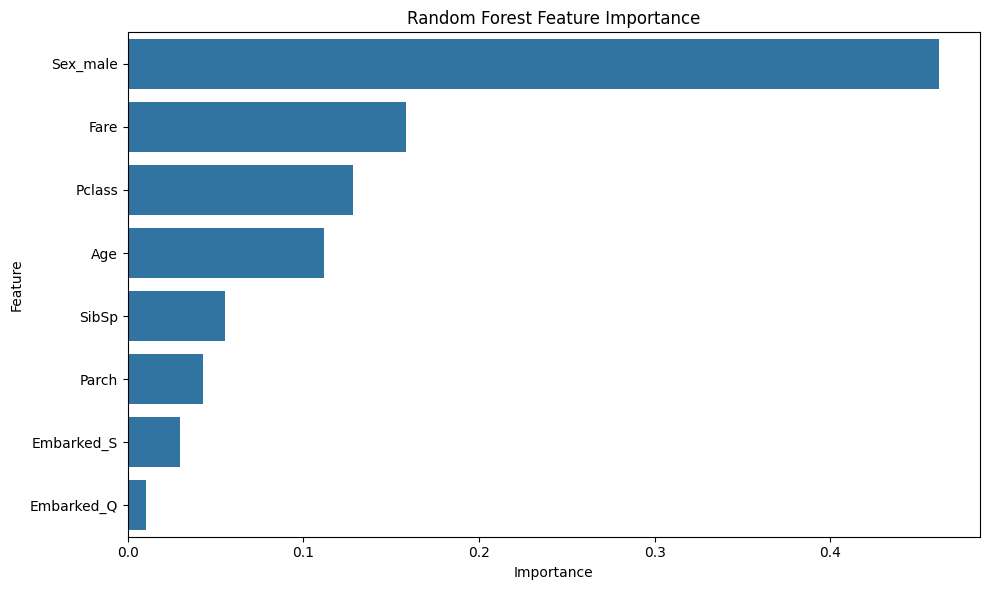

,Feature,Importance
0,Sex_male,0.462106
1,Fare,0.158593
2,Pclass,0.128553
3,Age,0.111780
4,SibSp,0.055659
5,Parch,0.043013
6,Embarked_S,0.029745
7,Embarked_Q,0.010549


In [107]:
importances = []
feature_names = []

# TODO: Implement
importances = model_for_importance.feature_importances_
feature_names = X_train_imputed.columns


fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# TODO: Sort here
fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)



plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

display(fi_df.head(10))

In [108]:
# ✏️ TODO: Which 3 features appear most important? Answer as comment.
# Sex_male, Pclass and Fare are the most important features.

## 10: Model Comparison and Reflection
To conclude the exercise, summarize the predictive performance of the different tree-based models and reflect on the trade-off between **accuracy** and **interpretability**.

1. Create a small summary table with the test accuracies of the Decision Tree, Random Forest, XGBoost, and tuned Random Forest.
2. Which model performs best on this split?
3. Which model would you choose if interpretability matters more than maximum accuracy?
4. Why do tree-based models usually not require feature scaling, while methods such as K-Means or PCA usually do?

When interpreting your results, remember that a single train/test split can differ from the more general trend described in the theory.

In [109]:
results = pd.DataFrame(
    {
        'Model': [
            'Decision Tree',
            'Random Forest',
            'XGBoost',
            'Tuned Random Forest',
        ],
        'Train Accuracy': [
            dt_train_acc,
            rf_train_acc,
            xgb_train_acc,
            tuned_rf_train_acc,
        ],
        'Test Accuracy': [
            dt_test_acc,
            rf_test_acc,
            xgb_test_acc,
            tuned_rf_test_acc,
        ],
    }
).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

display(results)

,Model,Train Accuracy,Test Accuracy
0,Random Forest,0.831901,0.858779
1,Tuned Random Forest,0.828080,0.854962
2,Decision Tree,0.811843,0.835878
3,XGBoost,0.937918,0.816794


In [110]:
# ✏️ TODO: Answer questions 2-4 above as comments.
# RandomForrest did perform the best
# I would choose decision tree, because it is understandable
# Tree based models do not need to be scaled, because they are based on thresholds and not on distances. 

## 11: Beyond Accuracy - Confusion Matrix
Accuracy gives only an overall summary of correct predictions. A **confusion matrix** gives more detailed information by separating the predictions into:
- **True Negatives (TN)**: predicted `Died`, actually `Died`
- **False Positives (FP)**: predicted `Survived`, actually `Died`
- **False Negatives (FN)**: predicted `Died`, actually `Survived`
- **True Positives (TP)**: predicted `Survived`, actually `Survived`

Use the model that performed best in Section 10 and inspect which type of error it makes more often.

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TODO: Choose the model you want to evaluate, e.g. rf_clf, best_rf, or xgb_clf.
model_for_confusion = xgb_clf


✏️ Create predictions on the corresponding test set. _Hint: `rf_clf` and `best_rf` use `X_test_imputed`, while `xgb_clf` uses `X_test`._

In [112]:
test_features_for_confusion = []
y_pred_confusion = []

# TODO: Implement:


test_features_for_confusion = X_test

y_pred_confusion = model_for_confusion.predict(test_features_for_confusion)

✏️ Plot the confusion matrix with class labels `['Died', 'Survived']`.

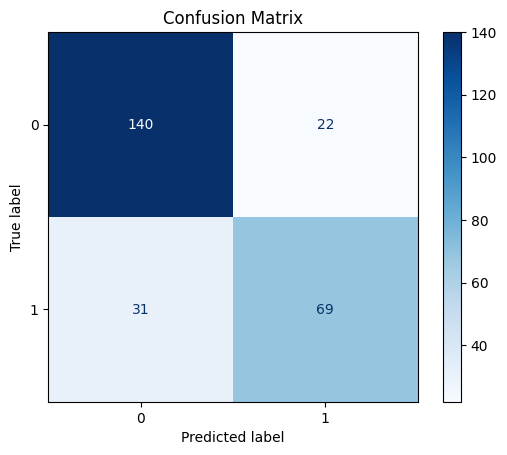

In [113]:
# TODO: Implement
plot_confusion_matrix = confusion_matrix(y_test, y_pred_confusion)
disp = ConfusionMatrixDisplay(confusion_matrix=plot_confusion_matrix, display_labels=model_for_confusion.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()



✏️ Print the raw confusion matrix values - which error type occurs more often: false positives or false negatives? Answer as comment.

In [55]:
# TODO: Implement
plot_confusion_matrix = confusion_matrix(y_test, y_pred_confusion)
print('Confusion matrix:')
print(plot_confusion_matrix)

false_positives = plot_confusion_matrix[0, 1]
false_negatives = plot_confusion_matrix[1, 0]
print('False positives:', false_positives)
print('False negatives:', false_negatives)

# If false_negatives > false_positives, then false negatives occur more often.
# If false_positives > false_negatives, then false positives occur more often.


Confusion matrix:
[[128  16]
 [ 42  76]]
False positives: 16
False negatives: 42


## 12: ✏️ Bagging vs. Boosting in Practice
The Random Forest and XGBoost models are both ensembles of trees, but they combine these trees in different ways.

Answer the following questions:
1. Which model is based on **bagging**, and which one is based on **boosting**?
2. Are the trees trained independently or sequentially?
3. Which approach mainly aims to reduce variance, and which one mainly tries to correct previous errors?
4. Looking at your results from Sections 6-11, what practical conclusion would you draw for this Titanic task?

In [ ]:
# 1. Tree is bagging, Random Forest is bagging, xgboost is boosting.

# 2. Trees are trained independently, while boosting trains trees sequentially, where each tree tries to correct the errors of the previous one.

# 3. Trees try to reduce variance, while boosting tries to reduce bias.

# 4. I would use random forest, execept if I need a more interpretable model, then I would choose a single decision tree.  